## Previsão de Tendência do Ibovespa

### Importação das bibliotecas

In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose

import plotly.graph_objects as go
from plotly.subplots import make_subplots

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.metrics import roc_auc_score, roc_curve

from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

import xgboost as xgb
from datetime import datetime, timedelta



import warnings
warnings.filterwarnings('ignore')

print("✅ Bibliotecas importadas com sucesso!")

✅ Bibliotecas importadas com sucesso!


In [16]:
#Definindo a semente para reprodutibilidade
SEED = np.random.seed(42)

### Aquisção os dados
-   Dados do Ibovespa obtidos do site Investing.com com príodo de 02/01/2020 a 01/07/2025

In [3]:
csv_file_path = "Dados_Históricos-Ibovespa_02_01_2020-01_07_2025.csv" 

def var_converter(var_str):
    '''Converte a columna %Var para valores numéricos:

       Remove o símbolo de porcentagem e substitui vírgulas por pontos
       
       Exemplo: '1,23%' se torna 1.23 como tipo float'''
    return float(var_str.replace('%', '').replace(',', '.')) 

def vol_converter(vol_str):
    """
    Converte uma string de volume (com sufixos 'K' para mil, 'M' para milhões, 'B' para bilhões)
    para um valor numérico (float). Também lida com vírgulas como separadores decimais.

    Exemplos:
    - '1.23M' se torna 1230000.0
    - '500K' se torna 500000.0
    - '2,5B' se torna 2500000000.0
    - '100' se torna 100.0

    Args:
        vol_str (str): A string de volume a ser convertida.

    Returns:
        float: O valor numérico do volume. Retorna 0.0 se a string for inválida ou vazia.
    """
    if not isinstance(vol_str, str) or not vol_str:
        return 0.0

    vol_str = vol_str.strip().upper().replace(',', '.')
    
    multipliers = {'K': 1e3, 'M': 1e6, 'B': 1e9}
    
    suffix = vol_str[-1]
    
    if suffix in multipliers:
        numeric_part = vol_str[:-1]
        multiplier = multipliers[suffix]
    else:
        numeric_part = vol_str
        multiplier = 1

    try:
        return float(numeric_part) * multiplier
    except ValueError:
        return 0.0

 

# Carrega o arquivo CSV com os dados históricos do Ibovespa
df = pd.read_csv(csv_file_path,
                  parse_dates=['Data'],
                  dayfirst=True,
                  decimal=',',
                  thousands='.',
                #   index_col='Data',
                  converters={'Var%': var_converter, 'Vol.': vol_converter})

print("📋 Primeiros registros:")
        
# Ordena por data (mais antigo primeiro)
df = df.sort_values(by='Data', ascending=True).reset_index(drop=True)
    
display(df.head())

print(f"✅ Dados carregados: {len(df)} registros de {df['Data'].min()} a {df['Data'].max()}")

📋 Primeiros registros:


,Data,Último,Abertura,Máxima,Mínima,Vol.,Var%
0,2020-01-02,118573,115652,118573,115649,5160000.0,2.53
1,2020-01-03,117707,118564,118792,117341,6830000.0,-0.73
2,2020-01-06,116878,117707,117707,116269,6570000.0,-0.70
3,2020-01-07,116662,116872,117076,115965,4850000.0,-0.18
4,2020-01-08,116247,116667,117335,115693,5910000.0,-0.36


✅ Dados carregados: 1368 registros de 2020-01-02 00:00:00 a 2025-07-01 00:00:00


###  Exploração dos Dados: 

In [5]:
# Informações básicas sobre os dados
print("📊 Tipos de Dados e Valores Nulos:")
print(df.info())
print("Quantidade de valores nulos por coluna:")
print(df.isnull().sum())

📊 Tipos de Dados e Valores Nulos:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1368 entries, 0 to 1367
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   Data      1368 non-null   datetime64[ns]
 1   Último    1368 non-null   int64         
 2   Abertura  1368 non-null   int64         
 3   Máxima    1368 non-null   int64         
 4   Mínima    1368 non-null   int64         
 5   Vol.      1368 non-null   float64       
 6   Var%      1368 non-null   float64       
dtypes: datetime64[ns](1), float64(2), int64(4)
memory usage: 74.9 KB
None
Quantidade de valores nulos por coluna:
Data        0
Último      0
Abertura    0
Máxima      0
Mínima      0
Vol.        0
Var%        0
dtype: int64


In [4]:
# Informações básicas sobre os dados
print("📊 Informações sobre os dados:")
print(f"Período: {df['Data'].min()} a {df['Data'].max()}")
print(f"Total de registros: {len(df)}")
print("Valores únicos por coluna:")
print(df.nunique())

📊 Informações sobre os dados:
Período: 2020-01-02 00:00:00 a 2025-07-01 00:00:00
Total de registros: 1368
Valores únicos por coluna:
Data        1368
Último      1341
Abertura    1343
Máxima      1351
Mínima      1346
Vol.         824
Var%         494
dtype: int64


In [6]:
# Estatísticas descritivas
print("📈 Estatísticas descritivas:")
display(df[['Último', 'Abertura', 'Máxima', 'Mínima', 'Vol.', 'Var%']].describe())

📈 Estatísticas descritivas:


,Último,Abertura,Máxima,Mínima,Vol.,Var%
count,1368.000000,1368.000000,1368.000000,1368.000000,1.368000e+03,1368.000000
mean,115052.598684,115035.621345,116036.609649,114052.283626,9.288247e+08,0.026360
std,13224.778877,13208.073784,12960.551134,13451.894508,3.056396e+09,1.579638
min,63570.000000,63604.000000,67604.000000,61691.000000,3.840000e+06,-14.780000
25%,106927.000000,106926.500000,108069.000000,105986.250000,8.977500e+06,-0.730000
50%,116085.500000,116035.000000,117074.000000,115161.000000,1.089000e+07,0.040000
75%,125669.750000,125667.250000,126551.500000,124873.250000,1.335250e+07,0.810000
max,140110.000000,140109.000000,140382.000000,138966.000000,2.487000e+10,13.910000


### Gráfico Candestick

In [7]:
fig = make_subplots(rows=2, cols=1)

fig.add_trace(go.Ohlc(x=df.Data,
                      open=df.Abertura,
                      high=df['Máxima'],
                      low=df['Mínima'],
                      close=df['Último'],
                      name='Preço'), row=1, col=1)

fig.add_trace(go.Scatter(x=df.Data, y=df['Vol.'], name='Volume'), row=2, col=1)

fig.update(layout_xaxis_rangeslider_visible=False)
fig.show()

### Decomposição de Série Temporal

In [8]:
df_time_serie = df[['Data','Último']]
df_time_serie.index = df_time_serie['Data']
df_time_serie = df_time_serie.drop(columns=['Data'])
df_time_serie

,Último
Data,
2020-01-02,118573
2020-01-03,117707
2020-01-06,116878
2020-01-07,116662
2020-01-08,116247
...,...
2025-06-25,135767
2025-06-26,137114
2025-06-27,136866


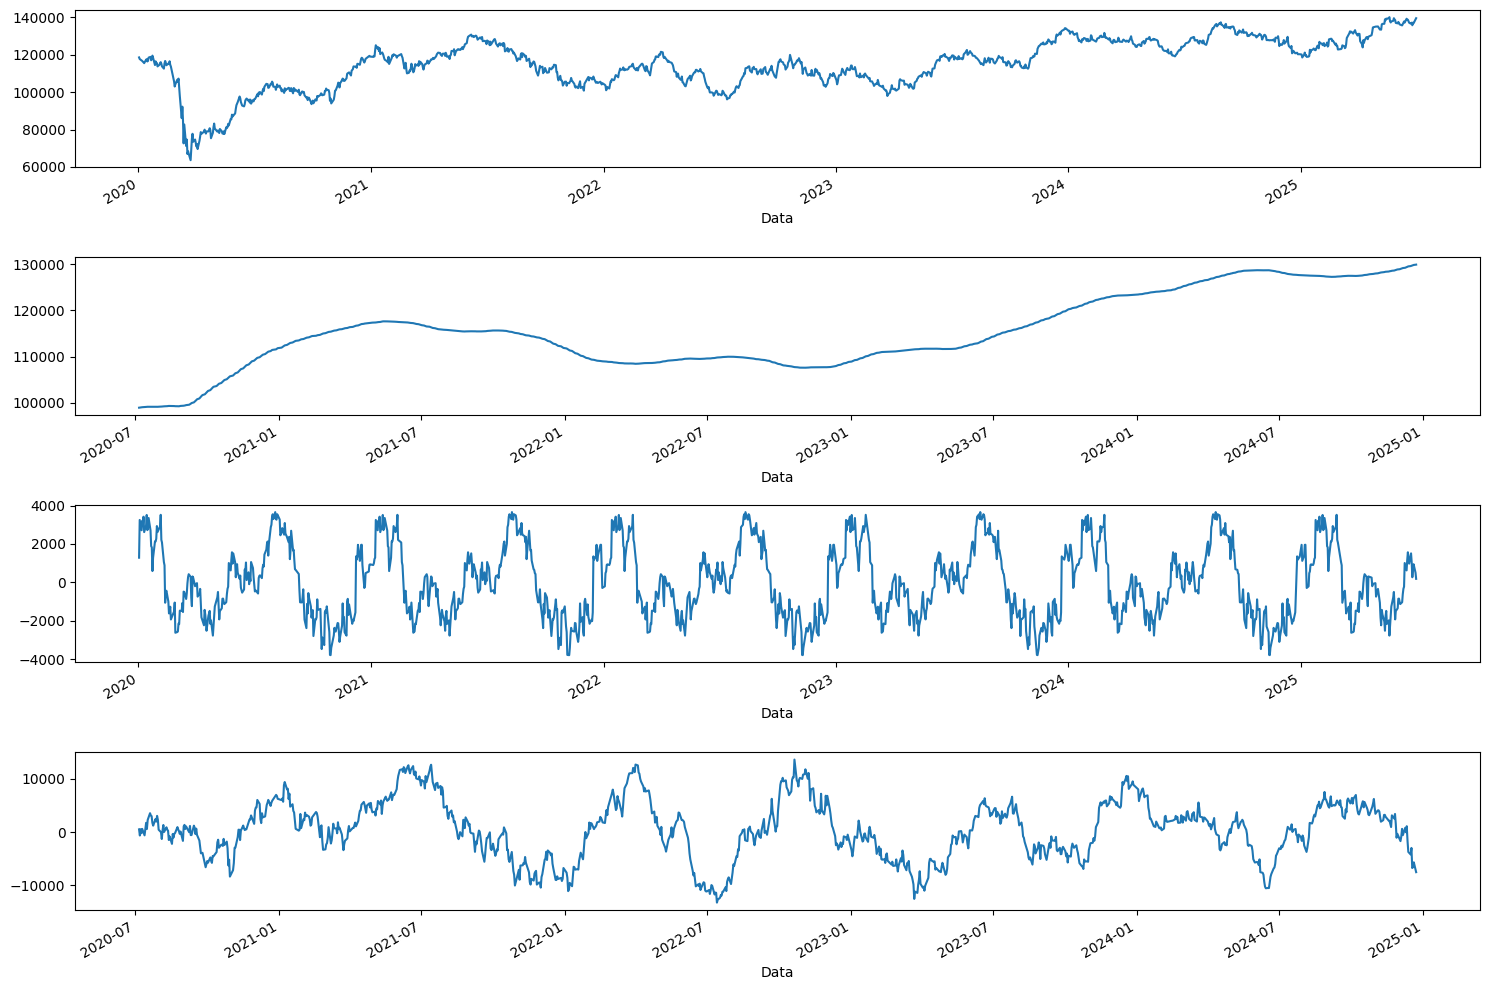

In [9]:
df_decomposta = seasonal_decompose(df_time_serie, model='additive', period=252)  # 252 dias úteis por ano

fig, (ax1,ax2,ax3,ax4) = plt.subplots(4,1, figsize = (15,10))

df_decomposta.observed.plot(ax=ax1)
df_decomposta.trend.plot(ax=ax2)
df_decomposta.seasonal.plot(ax=ax3)
df_decomposta.resid.plot(ax=ax4)

plt.tight_layout()

### Engenharia de Atributos

In [10]:
print("🔧 Criando features...")

# Cria cópia para não modificar original
df_features = df.copy()

# Cria a variável target (tendência do próximo dia)
df_features['Próximo_Fechamento'] = df_features['Último'].shift(-1)
df_features['Tendencia'] = (df_features['Próximo_Fechamento'] > df_features['Último']).astype(int)

# Features básicas
df_features['Retorno_1d'] = df_features['Último'].pct_change()
df_features['Retorno_2d'] = df_features['Último'].pct_change(2)
df_features['Retorno_3d'] = df_features['Último'].pct_change(3)

# Médias móveis
df_features['MA_5'] = df_features['Último'].rolling(window=5).mean()
df_features['MA_10'] = df_features['Último'].rolling(window=10).mean()
df_features['MA_20'] = df_features['Último'].rolling(window=20).mean()

# Posição relativa às médias móveis
df_features['Preco_vs_MA5'] = df_features['Último'] / df_features['MA_5'] - 1
df_features['Preco_vs_MA10'] = df_features['Último'] / df_features['MA_10'] - 1
df_features['Preco_vs_MA20'] = df_features['Último'] / df_features['MA_20'] - 1

# Volatilidade
df_features['Volatilidade_5d'] = df_features['Retorno_1d'].rolling(window=5).std()
df_features['Volatilidade_10d'] = df_features['Retorno_1d'].rolling(window=10).std()

# Amplitude diária
df_features['Amplitude'] = (df_features['Máxima'] - df_features['Mínima']) / df_features['Último']

# Gap de abertura
df_features['Gap_Abertura'] = (df_features['Abertura'] - df_features['Último'].shift(1)) / df_features['Último'].shift(1)

# RSI simplificado (aproximação)
delta = df_features['Último'].diff()
gain = (delta.where(delta > 0, 0)).rolling(window=14).mean()
loss = (-delta.where(delta < 0, 0)).rolling(window=14).mean()
rs = gain / loss
df_features['RSI'] = 100 - (100 / (1 + rs))

# Features temporais
df_features['Dia_Semana'] = df_features['Data'].dt.dayofweek
df_features['Mes'] = df_features['Data'].dt.month

# Variável target defasada (importante para séries temporais)
df_features['Tendencia_Anterior'] = df_features['Tendencia'].shift(1)

print("✅ Features criadas com sucesso!")
    

# Mostra as novas colunas criadas
print("📋 Novas features criadas:")
new_columns = [col for col in df_features.columns if col not in df.columns]
print(new_columns)

🔧 Criando features...
✅ Features criadas com sucesso!
📋 Novas features criadas:
['Próximo_Fechamento', 'Tendencia', 'Retorno_1d', 'Retorno_2d', 'Retorno_3d', 'MA_5', 'MA_10', 'MA_20', 'Preco_vs_MA5', 'Preco_vs_MA10', 'Preco_vs_MA20', 'Volatilidade_5d', 'Volatilidade_10d', 'Amplitude', 'Gap_Abertura', 'RSI', 'Dia_Semana', 'Mes', 'Tendencia_Anterior']


###  Análise da Variável Alvo

In [11]:
# Análise da distribuição da variável target
target_counts = df_features['Tendencia'].value_counts()
target_pct = df_features['Tendencia'].value_counts(normalize=True)

print("📊 Distribuição da Variável Target:")
print(f"Baixa (0): {target_counts[0]} ({target_pct[0]:.2%})")
print(f"Alta (1): {target_counts[1]} ({target_pct[1]:.2%})")

📊 Distribuição da Variável Target:
Baixa (0): 667 (48.76%)
Alta (1): 701 (51.24%)


### Preparação dos Dados para Modelagem

In [12]:
def prepare_train_test_split(df_features):
    """Prepara divisão temporal dos dados"""
    print("📊 Preparando divisão treino/teste...")
    
    # Remove linhas com valores nulos
    df_clean = df_features.dropna()
    
    # Seleciona features para o modelo
    feature_columns = [
        'Retorno_1d', 'Retorno_2d', 'Retorno_3d',
        'Preco_vs_MA5', 'Preco_vs_MA10', 'Preco_vs_MA20',
        'Volatilidade_5d', 'Volatilidade_10d',
        'Amplitude', 'Gap_Abertura', 'RSI',
        'Dia_Semana', 'Mes', 'Tendencia_Anterior'
    ]
    
    X = df_clean[feature_columns]
    y = df_clean['Tendencia']
    dates = df_clean['Data']
    
    # Divisão temporal: últimos 30 dias para teste
    split_date = dates.iloc[-30]
    train_mask = dates < split_date
    test_mask = dates >= split_date
    
    X_train = X[train_mask]
    X_test = X[test_mask]
    y_train = y[train_mask]
    y_test = y[test_mask]
    
    print("✅ Divisão realizada:")
    print(f"   - Treino: {len(X_train)} amostras")
    print(f"   - Teste: {len(X_test)} amostras")
    print(f"   - Data de corte: {split_date.strftime('%d/%m/%Y')}")
    
    return X_train, X_test, y_train, y_test, feature_columns

# Prepara os dados
X_train, X_test, y_train, y_test, feature_columns = prepare_train_test_split(df_features)

📊 Preparando divisão treino/teste...
✅ Divisão realizada:
   - Treino: 1318 amostras
   - Teste: 30 amostras
   - Data de corte: 19/05/2025


### Treinamento do Modelo Baseline - Regressão Logística

In [33]:
def train_baseline_model(X_train, y_train):
    """Treina o modelo baseline (Regressão Logística)"""
    print("🤖 Treinando modelo baseline...")
    
    # Normaliza as features
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    
    # Treina o modelo
    model = LogisticRegression(random_state=SEED, max_iter=1000)
    model.fit(X_train_scaled, y_train)
    
    print("✅ Modelo treinado com sucesso!")
    
    return model, scaler

# Treina o modelo
model, scaler = train_baseline_model(X_train, y_train)

🤖 Treinando modelo baseline...
✅ Modelo treinado com sucesso!


### Avaliação do Modelo

In [35]:
def evaluate_model(model, scaler, X_train, X_test, y_train, y_test, nome='Modelo Baseline'):
    """Avalia o modelo e exibe métricas"""
    print("📈 Avaliando modelo...")
    
    # Predições
    X_train_scaled = scaler.transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    y_train_pred = model.predict(X_train_scaled)
    y_test_pred = model.predict(X_test_scaled)
    
    y_train_prob = model.predict_proba(X_train_scaled)[:, 1]
    y_test_prob = model.predict_proba(X_test_scaled)[:, 1]
    
    # Métricas
    train_accuracy = accuracy_score(y_train, y_train_pred)
    test_accuracy = accuracy_score(y_test, y_test_pred)
    
    train_auc = roc_auc_score(y_train, y_train_prob)
    test_auc = roc_auc_score(y_test, y_test_prob)
    
    print("="*50)
    print(f"📊 RESULTADOS DO {nome.upper()}")
    print("="*50)
    print(f"Acurácia Treino: {train_accuracy:.4f} ({train_accuracy*100:.2f}%)")
    print(f"Acurácia Teste:  {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")
    print(f"AUC Treino:      {train_auc:.4f}")
    print(f"AUC Teste:       {test_auc:.4f}")
    
    # Verifica se atingiu a meta
    if test_accuracy >= 0.75:
        print("🎯 META ATINGIDA! Acurácia >= 75%")
    else:
        print(f"⚠️  Meta não atingida. Faltam {(0.75 - test_accuracy)*100:.2f}% para 75%")
    
    print("\n📋 Relatório de Classificação (Teste):")
    print(classification_report(y_test, y_test_pred, 
                              target_names=['Baixa', 'Alta']))
    
    # Análise de balanceamento
    print("\n⚖️  Distribuição das classes:")
    print(f"Treino - Alta: {y_train.mean():.2f} | Baixa: {1-y_train.mean():.2f}")
    print(f"Teste  - Alta: {y_test.mean():.2f} | Baixa: {1-y_test.mean():.2f}")
    
    return {
        'model_name': nome,
        'train_accuracy': train_accuracy,
        'test_accuracy': test_accuracy,
        'train_auc': train_auc,
        'test_auc': test_auc,
        'y_test_pred': y_test_pred,
        'y_test_prob': y_test_prob
    }

# Avalia o modelo
results_baseline = evaluate_model(model, scaler, X_train, X_test, y_train, y_test, nome='Modelo de Regressão Logística')

📈 Avaliando modelo...
📊 RESULTADOS DO MODELO DE REGRESSÃO LOGÍSTICA
Acurácia Treino: 0.5334 (53.34%)
Acurácia Teste:  0.6333 (63.33%)
AUC Treino:      0.5496
AUC Teste:       0.5475
⚠️  Meta não atingida. Faltam 11.67% para 75%

📋 Relatório de Classificação (Teste):
              precision    recall  f1-score   support

       Baixa       0.80      0.47      0.59        17
        Alta       0.55      0.85      0.67        13

    accuracy                           0.63        30
   macro avg       0.68      0.66      0.63        30
weighted avg       0.69      0.63      0.62        30


⚖️  Distribuição das classes:
Treino - Alta: 0.52 | Baixa: 0.48
Teste  - Alta: 0.43 | Baixa: 0.57


### XGBoost

In [42]:
def train_XGBoost_model(X_train, y_train):
    """Treina o modelo XGBoost"""
    print("🤖 Treinando modelo XGBoost...")
    
    # Normaliza as features
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)


    # Otimização de hiperparâmetros
    print("\nOtimizando hiperparâmetros...")
    param_grid = {
        'n_estimators': [ 200, 400, 500],
        'max_depth': [ 8, 9, 10],
        'learning_rate': [0.4, 0.5, 0.6, 0.7],
        'subsample': [0.5, 0.6, 0.7],
        'colsample_bytree': [0.5, 0.6, 0.7]
    }
    # Grid search com validação cruzada temporal
    xgb_model = xgb.XGBClassifier(
        objective='binary:logistic',
        eval_metric='logloss',
        random_state=SEED
    )

    grid_search = GridSearchCV(
        xgb_model, 
        param_grid,
        cv=5,  # 5-fold cross validation
        scoring='accuracy',
        n_jobs=-1,
        verbose=1
    )


    grid_search.fit(X_train_scaled, y_train)
    print(f"Melhores parâmetros: {grid_search.best_params_}")
    model = grid_search.best_estimator_
        
    
    print("✅ Modelo treinado com sucesso!")
    
    return model, scaler

model_xgboost, scaler_xgboost = train_XGBoost_model(X_train, y_train)

🤖 Treinando modelo XGBoost...

Otimizando hiperparâmetros...
Fitting 5 folds for each of 324 candidates, totalling 1620 fits
Melhores parâmetros: {'colsample_bytree': 0.6, 'learning_rate': 0.4, 'max_depth': 8, 'n_estimators': 200, 'subsample': 0.6}
✅ Modelo treinado com sucesso!


In [43]:
# Avalia o modelo
results_XGBoost = evaluate_model(model_xgboost, scaler_xgboost, X_train, X_test, y_train, y_test, nome='Modelo XGBoost')

📈 Avaliando modelo...
📊 RESULTADOS DO MODELO XGBOOST
Acurácia Treino: 1.0000 (100.00%)
Acurácia Teste:  0.5667 (56.67%)
AUC Treino:      1.0000
AUC Teste:       0.4977
⚠️  Meta não atingida. Faltam 18.33% para 75%

📋 Relatório de Classificação (Teste):
              precision    recall  f1-score   support

       Baixa       0.61      0.65      0.63        17
        Alta       0.50      0.46      0.48        13

    accuracy                           0.57        30
   macro avg       0.56      0.55      0.55        30
weighted avg       0.56      0.57      0.56        30


⚖️  Distribuição das classes:
Treino - Alta: 0.52 | Baixa: 0.48
Teste  - Alta: 0.43 | Baixa: 0.57


In [46]:

def train_random_forest_model(X_train, y_train):
    """Treina o modelo Random Forest"""
    print("🤖 Treinando modelo Random Forest...")
    
    # Normaliza as features
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    
    # Treina o modelo
    model = RandomForestClassifier(random_state=SEED)
    model.fit(X_train_scaled, y_train)
    
    print("✅ Modelo treinado com sucesso!")
    
    return model, scaler

# Treina o modelo
model_random_forest, scaler_random_forest = train_random_forest_model(X_train, y_train)

🤖 Treinando modelo Random Forest...
✅ Modelo treinado com sucesso!


In [47]:
# Avalia o modelo
results_random_forest = evaluate_model(model_random_forest, scaler_random_forest, X_train, X_test, y_train, y_test, nome='Modelo Random Forest')

📈 Avaliando modelo...
📊 RESULTADOS DO MODELO RANDOM FOREST
Acurácia Treino: 1.0000 (100.00%)
Acurácia Teste:  0.4667 (46.67%)
AUC Treino:      1.0000
AUC Teste:       0.5271
⚠️  Meta não atingida. Faltam 28.33% para 75%

📋 Relatório de Classificação (Teste):
              precision    recall  f1-score   support

       Baixa       0.52      0.65      0.58        17
        Alta       0.33      0.23      0.27        13

    accuracy                           0.47        30
   macro avg       0.43      0.44      0.43        30
weighted avg       0.44      0.47      0.45        30


⚖️  Distribuição das classes:
Treino - Alta: 0.52 | Baixa: 0.48
Teste  - Alta: 0.43 | Baixa: 0.57


In [49]:
def train_svc_model(X_train, y_train):
    """Treina o modelo SVC"""
    print("🤖 Treinando modelo SVC...")
    
    # Normaliza as features
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    
    # Treina o modelo
    model = SVC(random_state=SEED)
    model.fit(X_train_scaled, y_train)
    
    print("✅ Modelo treinado com sucesso!")
    
    return model, scaler

# Treina o modelo
model_svc, scaler_svc = train_svc_model(X_train, y_train)




🤖 Treinando modelo SVC...
✅ Modelo treinado com sucesso!


In [51]:
# Avalia o modelo
# results_svc = evaluate_model(model_svc, scaler_svc, X_train, X_test, y_train, y_test, nome='Modelo SVC')

In [53]:
def train_KNeighbors_model(X_train, y_train):
    """Treina o modelo KNeighbors"""
    print("🤖 Treinando modelo KNeighbors...")
    
    # Normaliza as features
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    
    # Treina o modelo
    model = KNeighborsClassifier()
    model.fit(X_train_scaled, y_train)
    
    print("✅ Modelo treinado com sucesso!")
    
    return model, scaler

# Treina o modelo
model_KNeighbors, scaler_KNeighbors = train_KNeighbors_model(X_train, y_train)
# Avalia o modelo
results_KNeighbors = evaluate_model(model_KNeighbors, scaler_KNeighbors, X_train, X_test, y_train, y_test, nome='Modelo KNeighbors')

🤖 Treinando modelo KNeighbors...
✅ Modelo treinado com sucesso!
📈 Avaliando modelo...
📊 RESULTADOS DO MODELO KNEIGHBORS
Acurácia Treino: 0.6882 (68.82%)
Acurácia Teste:  0.4333 (43.33%)
AUC Treino:      0.7454
AUC Teste:       0.3394
⚠️  Meta não atingida. Faltam 31.67% para 75%

📋 Relatório de Classificação (Teste):
              precision    recall  f1-score   support

       Baixa       0.50      0.41      0.45        17
        Alta       0.38      0.46      0.41        13

    accuracy                           0.43        30
   macro avg       0.44      0.44      0.43        30
weighted avg       0.45      0.43      0.44        30


⚖️  Distribuição das classes:
Treino - Alta: 0.52 | Baixa: 0.48
Teste  - Alta: 0.43 | Baixa: 0.57


In [ ]:
    # "Gradient Boosting": GradientBoostingClassifier(random_state=42),